# Laboratorio: Regresión Polinomial Multivariable
### Predicción de la Temperatura Crítica de Superconductores

En este proyecto de laboratorio, mi objetivo principal es desarrollar un modelo predictivo de Machine Learning capaz de inferir la **temperatura crítica** (`critical_temp`, medida en grados Kelvin) a la que un material adquiere propiedades de superconductor.

Para lograrlo, utilizo un dataset detallado que contiene docenas de características físicas y químicas extraídas de la fórmula de diversos materiales (como masa atómica, densidad, afinidad electrónica, conductividad térmica, radio atómico, valencia, entre otras). Dado que la relación entre la composición de un material y su temperatura crítica es altamente compleja y no lineal, implementaré un modelo de **Regresión Polinomial Multivariable**. A lo largo de este cuaderno, demostraré el flujo completo de trabajo: desde la limpieza y preprocesamiento de los datos, pasando por el entrenamiento del modelo (utilizando tanto el Descenso por el Gradiente como la Ecuación Normal), hasta llegar a la validación final de mis inferencias comprobando el margen de error con datos de prueba nunca antes vistos por el algoritmo.

En esta primera celda, importo las librerías base como pandas y numpy, y cargo el dataset de temperaturas críticas de los superconductores. Para realizar un trabajo riguroso y evitar que el modelo simplemente memorice los datos (overfitting), separo el conjunto en dos partes: reservo las primeras 100 filas exclusivamente como datos de prueba (Test) para evaluar el modelo de forma imparcial al final del laboratorio, y utilizo el resto de las más de 21,000 filas como mi conjunto de entrenamiento (Train) para enseñar al algoritmo.



In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Carga, Limpieza y Exploración Inicial de los Datos
En esta primera celda, realizo la carga de mi dataset original desde mi unidad de Google Drive utilizando la librería `pandas`. Antes de aplicar cualquier algoritmo de Machine Learning, es vital garantizar la calidad y consistencia de los datos. Por ello, ejecuto un proceso de limpieza inicial: primero, contabilizo y elimino todas las filas duplicadas que podrían generar un sesgo en el aprendizaje de mi modelo; segundo, verifico la integridad de la información buscando valores nulos o vacíos (`NaN`) para evitar errores matemáticos al operar con matrices. Finalmente, imprimo las dimensiones exactas de mi dataset limpio (filas y columnas) y extraigo la lista de variables disponibles para conocer la estructura exacta de la información con la que voy a trabajar.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/sis420/Laboratorios/Lab 2/train.csv')

duplicados = df.duplicated().sum()
print(f"Hay {duplicados} filas repetidas en el dataset.")
df.drop_duplicates(inplace=True)
print(f"Ahora hay {df.duplicated().sum()} filas repetidas.")
print(df.isnull().sum())
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.columns

Hay 66 filas repetidas en el dataset.
Ahora hay 0 filas repetidas.
number_of_elements       0
mean_atomic_mass         0
wtd_mean_atomic_mass     0
gmean_atomic_mass        0
wtd_gmean_atomic_mass    0
                        ..
range_Valence            0
wtd_range_Valence        0
std_Valence              0
wtd_std_Valence          0
critical_temp            0
Length: 82, dtype: int64
Filas: 21197, Columnas: 82


Index(['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass',
       'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass',
       'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass',
       'std_atomic_mass', 'wtd_std_atomic_mass', 'mean_fie', 'wtd_mean_fie',
       'gmean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie',
       'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie',
       'mean_atomic_radius', 'wtd_mean_atomic_radius', 'gmean_atomic_radius',
       'wtd_gmean_atomic_radius', 'entropy_atomic_radius',
       'wtd_entropy_atomic_radius', 'range_atomic_radius',
       'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius',
       'mean_Density', 'wtd_mean_Density', 'gmean_Density',
       'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density',
       'range_Density', 'wtd_range_Density', 'std_Density', 'wtd_std_Density',
       'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity',
       'gmean_

### Selección de Características y Partición del Dataset (Train/Test)
En este paso, selecciono cuidadosamente 21 características físicas y químicas específicas de mi dataset (como la masa atómica media, el radio atómico, la densidad, entre otras) para conformar mi matriz de variables independientes $X$, y defino la 'temperatura crítica' como mi vector objetivo $y$. Una vez extraídos los datos en formato de arreglos de NumPy (`X_completo` y `y_completo`), realizo la partición fundamental de mi proyecto para evitar el sesgo: separo las primeras 100 filas para crear mi conjunto de prueba (`X_test` y `y_test`), el cual mantendré completamente aislado hasta la evaluación final del modelo. El resto de las observaciones (más de 21,000 registros) las asigno a mis variables de entrenamiento (`X` e `y`). Finalmente, calculo el tamaño de la muestra de entrenamiento $m$ e imprimo un resumen con las dimensiones y el contenido de las matrices para confirmar que la separación se ejecutó de manera correcta antes de pasar a la fase matemática.

In [ ]:
# 2. Seleccionar  21 columnas de características (X) y la columna objetivo (y)
columnas_x = [
    'mean_atomic_mass', 'wtd_mean_atomic_mass', 'std_atomic_mass', 'range_atomic_mass',
    'mean_fie', 'wtd_mean_fie', 'mean_atomic_radius', 'wtd_mean_atomic_radius',
    'std_atomic_radius', 'range_atomic_radius', 'mean_Density', 'wtd_mean_Density',
    'mean_ElectronAffinity', 'wtd_mean_ElectronAffinity', 'mean_FusionHeat',
    'wtd_mean_FusionHeat', 'mean_ThermalConductivity', 'wtd_mean_ThermalConductivity',
    'mean_Valence', 'wtd_mean_Valence', 'number_of_elements'
]

X_completo = df[columnas_x].values
y_completo = df['critical_temp'].values

# ==========================================
# 4. SPLIT: SEPARAR TEST Y TRAIN
# ==========================================
# TEST: Sacamos las primeras 100 filas para probar al final
X_test = X_completo[:100, :]
y_test = y_completo[:100]

# TRAIN: Usamos desde la fila 100 en adelante para entrenar
X = X_completo[100:, :]
y = y_completo[100:]
m=y.size
print(f"Dataset listo: {X.shape[0]} filas y {X.shape[1]} columnas.")
print(f"La matris X tiene {X}")
print(f"El vector y tiene {y}")


Dataset listo: 21097 filas y 21 columnas.
La matris X tiene [[76.4445625  51.24566538 43.82335412 ...  2.25        2.07692308
   4.        ]
 [79.736926   51.23974613 39.74604034 ...  2.8         2.19354839
   5.        ]
 [91.8081     50.94721    54.87713673 ...  2.25        2.09
   4.        ]
 ...
 [99.66319    95.609104    6.75681    ...  4.5         4.8
   2.        ]
 [99.66319    97.0956022   6.75681    ...  4.5         4.69
   2.        ]
 [87.46833333 86.8585     29.90528168 ...  5.          4.5
   3.        ]]
El vector y tiene [85.5  77.3  69.   ...  1.98  1.84 12.8 ]


### Análisis Exploratorio Visual de los Datos
En esta celda, defino e implemento una función personalizada llamada `plotData` para realizar una exploración visual detallada de mi conjunto de entrenamiento. Mi objetivo con este paso es analizar gráficamente el comportamiento y la relación individual de cada una de mis 21 características independientes frente a la temperatura crítica (variable objetivo). Para organizar la visualización de forma limpia, utilizo la librería `matplotlib` y configuro una cuadrícula estructurada de 7 filas por 3 columnas, lo que me da exactamente los 21 espacios necesarios. Mediante un ciclo iterativo, recorro cada característica extrayendo su columna correspondiente de la matriz $X$ y genero un diagrama de dispersión (*scatter plot*) contra el vector $y$, aplicando una ligera transparencia a los puntos para identificar fácilmente las zonas con mayor densidad de datos. Finalmente, etiqueto los ejes de cada subgráfico y aseguro que cualquier espacio sobrante en la figura se oculte, obteniendo así un panorama visual completo que justifica la necesidad de aplicar transformaciones polinomiales a mis datos.

In [ ]:
def plotData(X, y, feature_names):
    """
    Grafica múltiples variables independientes contra la variable objetivo.
    X: Matriz con las 21 columnas originales.
    y: Vector de temperatura crítica.
    feature_names: Lista con los nombres de las 21 columnas.
    """
    # Configuramos una cuadrícula de 7 filas x 3 columnas (total 21 espacios)
    fig, axes = pyplot.subplots(7, 3, figsize=(15, 30))
    fig.subplots_adjust(hspace=0.5)
    axes = axes.flatten() # Convertimos la matriz de ejes en una lista simple

    for i in range(len(feature_names)):
        # Graficamos cada característica en su propio subgráfico
        axes[i].plot(X[:, i], y, 'ro', ms=3, mec='k', alpha=0.5)
        axes[i].set_xlabel(feature_names[i])
        axes[i].set_ylabel('Temp Crítica (K)')
        axes[i].set_title(f'{feature_names[i]} vs Temp')

    # Si sobran espacios en la cuadrícula, los ocultamos
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    pyplot.show()




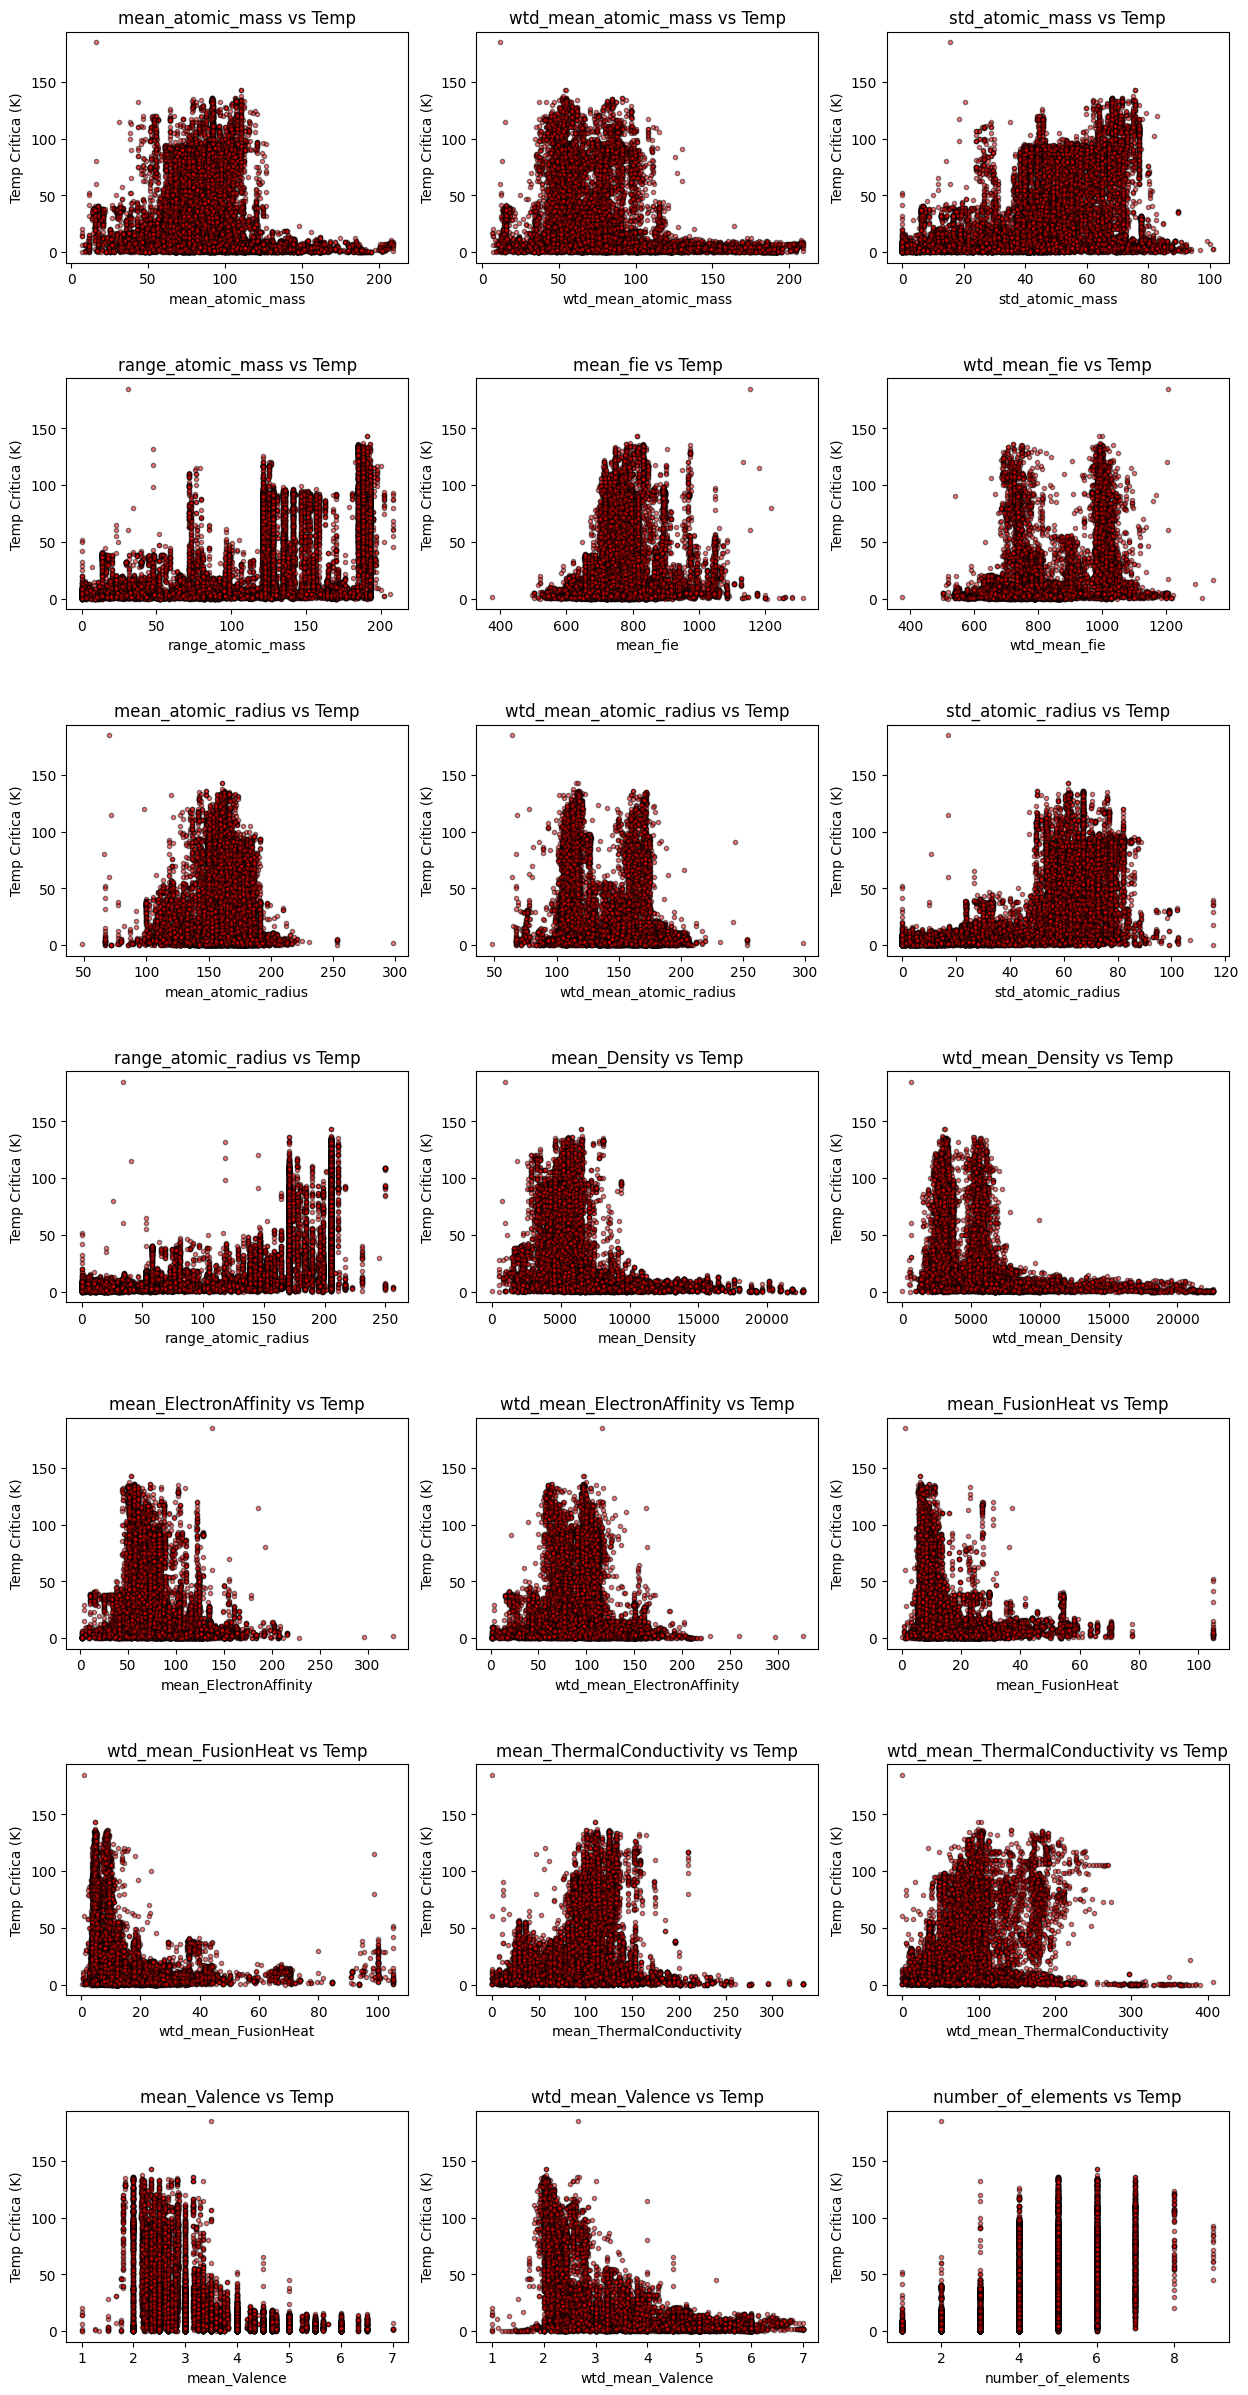

In [ ]:
plotData(X, y,columnas_x)

### Transformación Polinomial de las Características
En esta línea de código, ejecuto la transformación matemática central de mi modelo para convertirlo en una Regresión Polinomial. Lo que hago es tomar mi matriz original de características de entrenamiento $X$ y concatenarla horizontalmente (`axis=1`) con el cuadrado exacto de esas mismas variables (`X * X`). Con este procedimiento, expando directamente mi espacio de características (pasando de 21 a 42 columnas), lo cual es fundamental para dotar al algoritmo de la flexibilidad necesaria para capturar patrones y relaciones no lineales complejas entre las propiedades de los materiales y su temperatura crítica, algo que un modelo estrictamente lineal jamás podría aprender con precisión.

In [ ]:
X = np.concatenate([X, X * X], axis=1)

In [ ]:
print(X)

[[76.4445625  51.24566538 43.82335412 ...  5.0625      4.31360947
  16.        ]
 [79.736926   51.23974613 39.74604034 ...  7.84        4.81165453
  25.        ]
 [91.8081     50.94721    54.87713673 ...  5.0625      4.3681
  16.        ]
 ...
 [99.66319    95.609104    6.75681    ... 20.25       23.04
   4.        ]
 [99.66319    97.0956022   6.75681    ... 20.25       21.9961
   4.        ]
 [87.46833333 86.8585     29.90528168 ... 25.         20.25
   9.        ]]


Aquí defino mi función de normalización matemática featureNormalize, la cual es vital porque mis 21 variables físicas tienen rangos numéricos drásticamente diferentes. Utilizo el método Z-score restando la media y dividiendo por la desviación estándar calculada por columna, e incluyo una validación de seguridad matemática para convertir cualquier desviación de cero a uno, evitando así errores críticos de división por cero que arruinarían el entrenamiento y generarían valores nulos.

In [ ]:
def featureNormalize(X):
    # Convertimos a numpy array si es un objeto de Pandas
    if isinstance(X, (pd.DataFrame, pd.Series)):
        X = X.to_numpy()

    # Si es un vector (como la y), lo transformamos a matriz de una columna
    is_vector = False
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
        is_vector = True

    X_norm = np.copy(X).astype(float)
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    # Evitar división por cero
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma

    # Si entró como vector, devolvemos un vector (aplanado)
    if is_vector:
        return X_norm.flatten(), mu[0], sigma[0]
    else:
        return X_norm, mu, sigma

### Normalización del Conjunto de Entrenamiento
En esta celda, aplico la función de normalización que definí previamente tanto a mis variables independientes (la matriz $X$) como a mi variable objetivo (el vector $y$). Al ejecutar `featureNormalize(X)`, transformo todas las características polinomiales de los materiales para que compartan una escala común centrada en cero, almacenando los valores estandarizados en `X_norm`, y guardando las medias en `mu` y las desviaciones estándar en `sigma` (parámetros cruciales que necesitaré más adelante para normalizar los datos de prueba bajo la misma regla). De manera similar, normalizo las temperaturas críticas obteniendo `y_norm`, `muy` y `sigmay`; tomé esta decisión técnica para maximizar la estabilidad numérica y acelerar drásticamente la convergencia del algoritmo de Descenso por el Gradiente, teniendo siempre en cuenta que al momento de hacer inferencias deberé usar estos parámetros guardados para revertir la escala (des-normalizar) y obtener mis predicciones finales en grados Kelvin reales.

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)
y_norm,muy,sigmay= featureNormalize(y)
#print(X)
#print('Media calculada:', mu)
#print('Desviación estandar calculada:', sigma)

In [ ]:

print(X_norm)

[[-0.37428774 -0.6491691  -0.02955802 ... -0.79623534 -0.79380017
  -0.25131502]
 [-0.26344328 -0.64934574 -0.23282907 ... -0.44288106 -0.73770785
   0.49111083]
 [ 0.14295862 -0.65807583  0.52151902 ... -0.79623534 -0.78766318
  -0.25131502]
 ...
 [ 0.40741704  0.67475901 -1.87747941 ...  1.13592241  1.31525927
  -1.24121614]
 [ 0.40741704  0.71912024 -1.87747941 ...  1.13592241  1.19769005
  -1.24121614]
 [-0.00314891  0.4136167  -0.72343182 ...  1.74021866  1.00103557
  -0.82875734]]


In [ ]:
print(y_norm)

[ 1.49184158  1.25247779  1.01019492 ... -0.94616623 -0.95025292
 -0.63032278]


### Visualización de los Datos Normalizados
En esta celda, vuelvo a hacer uso de mi función personalizada `plotData`, pero en esta ocasión le paso mis matrices ya procesadas: `X_norm` e `y_norm`. El objetivo principal de este paso es realizar una verificación visual rápida (un *sanity check*) para comprobar que la estandarización matemática se aplicó de manera exitosa. A diferencia de los gráficos exploratorios iniciales, al observar estas nuevas gráficas noto que los ejes ya no muestran las magnitudes físicas originales y dispares de los materiales (como densidades altísimas o radios atómicos minúsculos), sino que todos los puntos están ahora comprimidos en una escala estándar centrada alrededor del cero. Esto me da la certeza técnica de que mi dataset está perfectamente balanceado y listo para ser introducido al algoritmo de Descenso por el Gradiente, garantizando que ninguna característica dominará matemáticamente a las demás solo por tener valores numéricos más grandes.



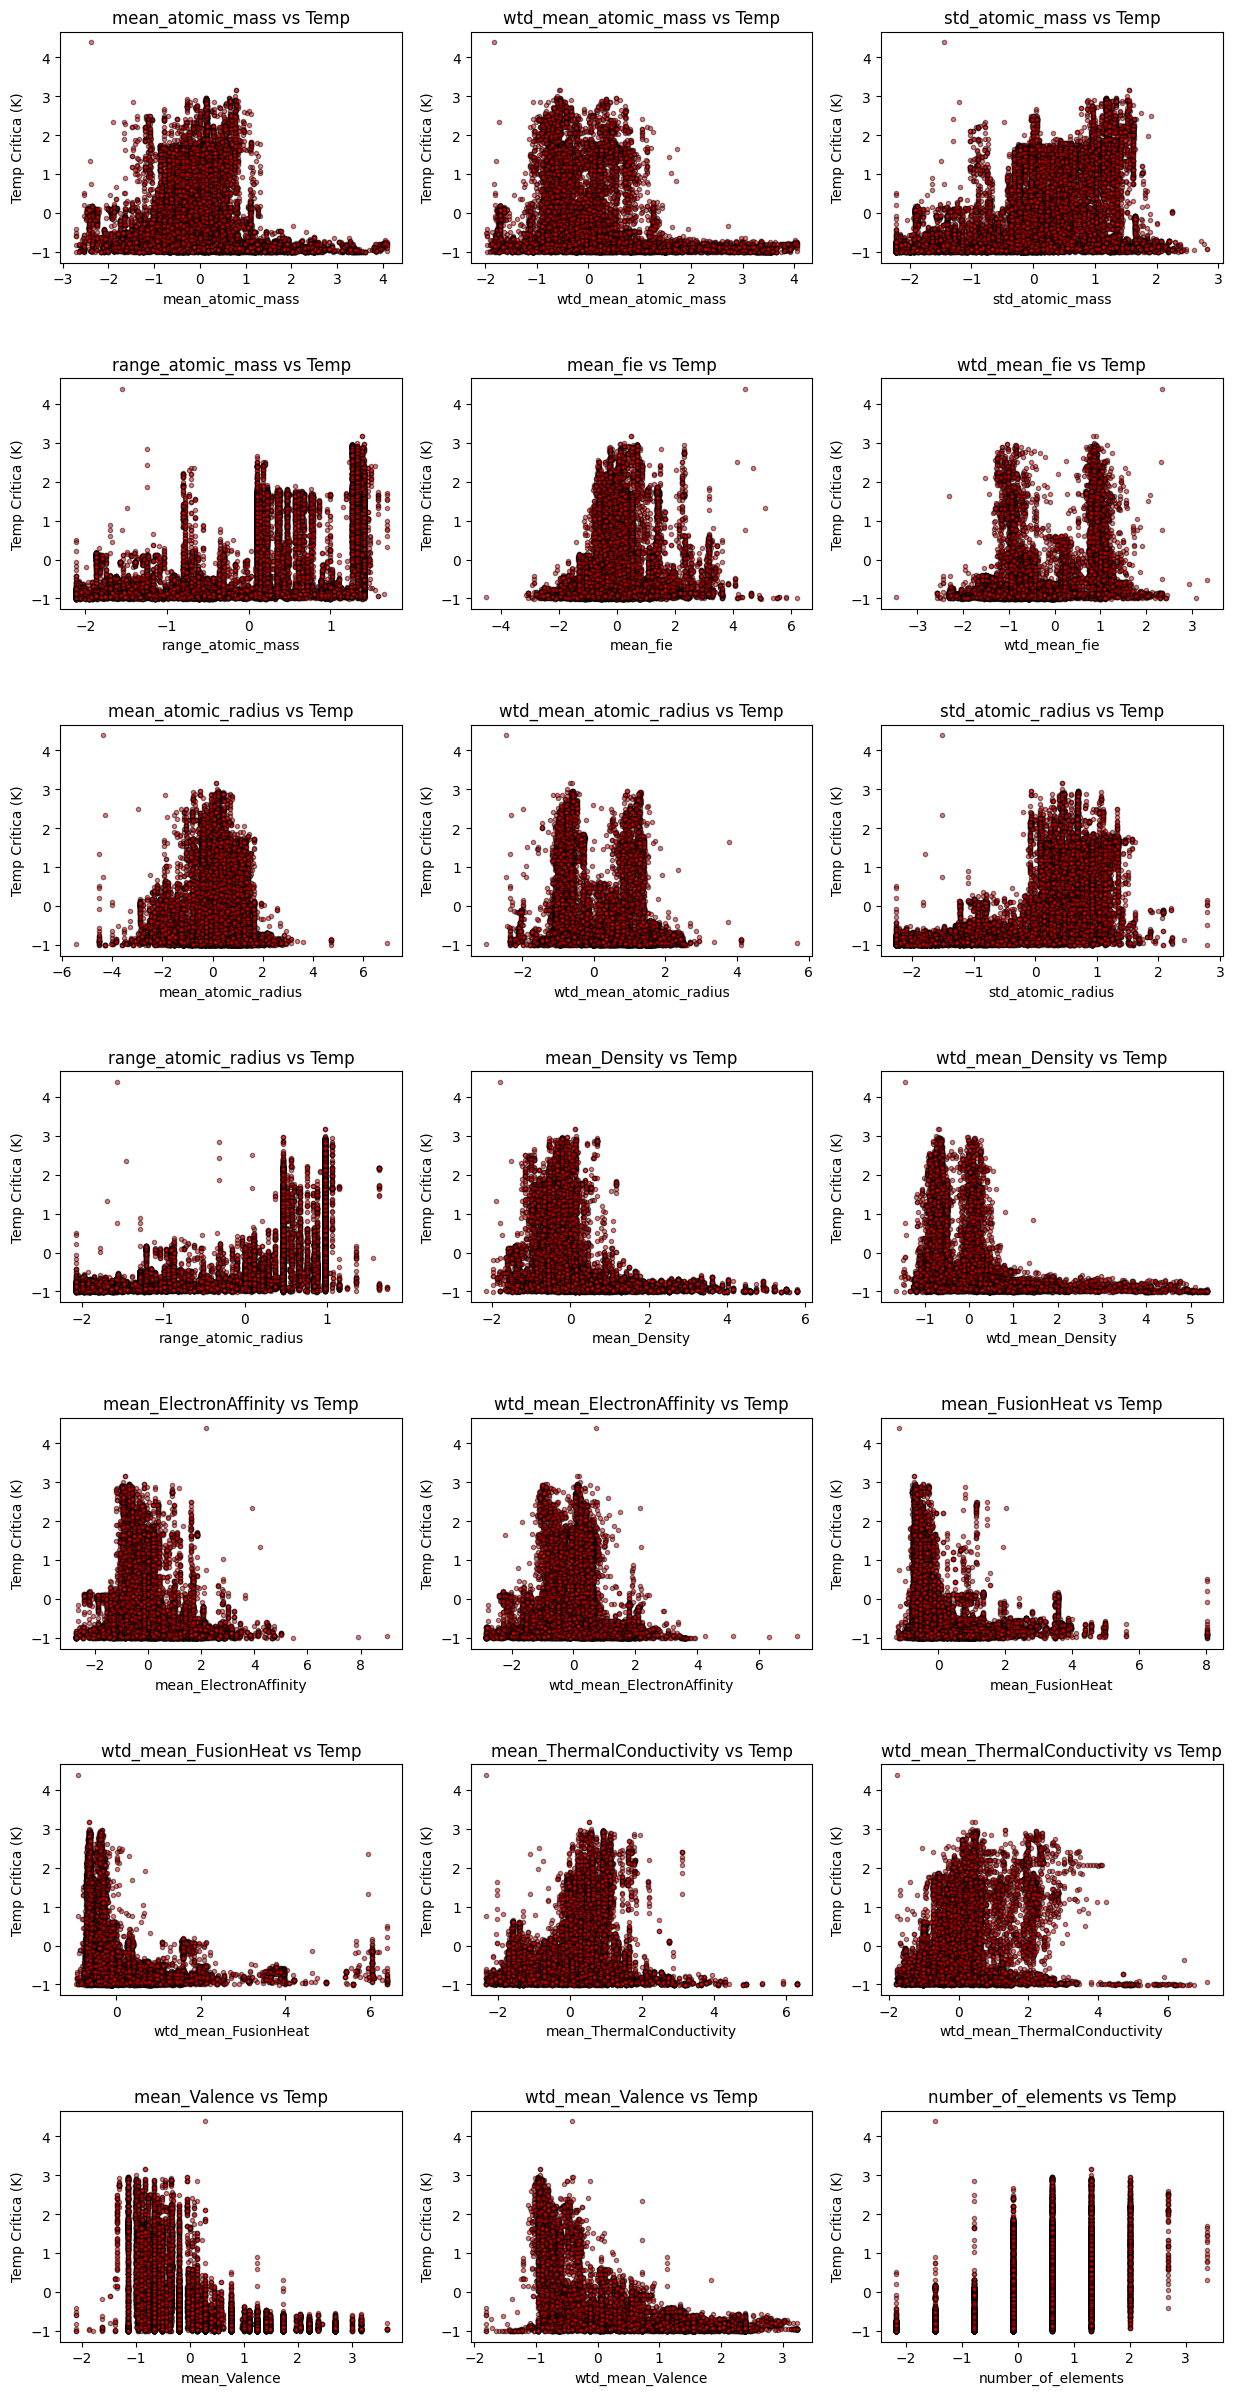

In [ ]:
plotData(X_norm, y_norm,columnas_x)

### Inserción del Término de Sesgo (Bias)
En esta línea de código, completo la estructura final de mi matriz de entrenamiento incorporando el término independiente o de sesgo (*bias*). Utilizando la función `np.ones`, construyo un vector columna compuesto enteramente por unos, con una longitud exactamente igual a la cantidad de mis muestras de entrenamiento ($m$). Posteriormente, concateno este vector horizontalmente (`axis=1`) en la primera posición izquierda de mi matriz previamente normalizada `X_norm`. Este artificio matricial es estrictamente obligatorio para el correcto funcionamiento del modelo de Regresión, ya que representa la característica artificial $X_0 = 1$ que se multiplicará por mi parámetro $\theta_0$; esto le otorga al algoritmo el grado de libertad matemático necesario para que la curva de predicción pueda cruzar el eje Y en cualquier punto óptimo, evitando que el modelo quede anclado forzosamente al origen (0,0).

In [ ]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
#X_norm = np.concatenate([X_norm, X_norm * X_norm], axis=1)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [ ]:
print(X)

[[ 1.         -0.37428774 -0.6491691  ... -0.79623534 -0.79380017
  -0.25131502]
 [ 1.         -0.26344328 -0.64934574 ... -0.44288106 -0.73770785
   0.49111083]
 [ 1.          0.14295862 -0.65807583 ... -0.79623534 -0.78766318
  -0.25131502]
 ...
 [ 1.          0.40741704  0.67475901 ...  1.13592241  1.31525927
  -1.24121614]
 [ 1.          0.40741704  0.71912024 ...  1.13592241  1.19769005
  -1.24121614]
 [ 1.         -0.00314891  0.4136167  ...  1.74021866  1.00103557
  -0.82875734]]


En esta sección programo el núcleo matemático del modelo implementando las funciones computeCostMulti y gradientDescentMulti. La primera se encarga de calcular el error cuadrático medio $J(\theta)$ actual entre mis predicciones y los valores reales de temperatura, mientras que la segunda actualiza iterativamente mis parámetros $\theta$ restándoles el gradiente multiplicado por la tasa de aprendizaje $\alpha$, buscando siempre el punto mínimo de error en la función de costo.

In [ ]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [ ]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

En esta celda preparo los datos y ejecuto el Descenso por el Gradiente. Para capturar el comportamiento no lineal de los materiales, concateno mis 21 variables originales de entrenamiento con sus valores al cuadrado, creando una matriz polinomial de 42 columnas. Luego, normalizo esta nueva matriz, le agrego la columna de unos para el sesgo (llegando a 43 columnas) y entreno el modelo. Al final, grafico el historial del costo para demostrar visualmente cómo el error de mi modelo cae iteración tras iteración hasta estabilizarse cerca de cero.


theta calculado por el descenso por el gradiente: [ 2.45428385e-16  6.26713633e-01 -9.88673384e-01  8.01691617e-01
 -1.24160431e+00  3.23372199e-01  2.90764804e-01 -4.92873726e-02
  7.02166400e-01  1.96938023e-01 -4.41578041e-01 -4.81600817e-01
  2.92198921e-01 -1.22527059e-01  1.70241994e-01  8.05924463e-02
 -2.13989140e-01  8.21380107e-02  4.87100514e-01 -2.71194901e-01
 -8.66031595e-01  2.15913540e-01 -3.77936195e-01  7.80202919e-01
 -5.95139320e-01  1.16440283e+00 -1.79736964e-01 -2.27695756e-01
  2.39884411e-02 -3.46783734e-01 -4.12929797e-01  9.24316819e-01
  1.60047013e-01 -2.94518291e-01  5.79809574e-02 -1.61939506e-01
 -4.95629706e-02  8.59439122e-02 -3.20107960e-02 -3.57666746e-01
  2.61656222e-01  8.16880701e-01 -2.11442800e-01]
El error es: 0.1628214691083124


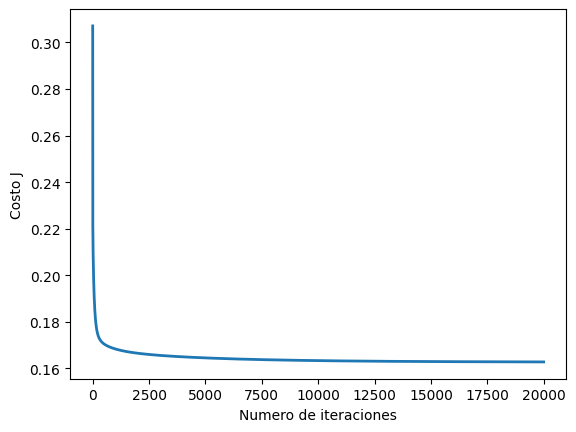

In [ ]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.1
num_iters = 20000
# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1])

# ejecuta el descenso por el gradiente
theta, J_history = gradientDescentMulti(X, y_norm, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print('El error es:',J_history[-1])


En esta última etapa, evalúo el rendimiento de mi modelo entrenado por Descenso por el Gradiente utilizando los 100 datos de prueba (Test). Para que el cálculo sea válido, primero preparo estos datos aplicándoles exactamente la misma transformación que usé en el entrenamiento: los concateno con sus cuadrados para formar el polinomio y los normalizo estrictamente utilizando la media (`mu`) y desviación estándar (`sigma`) que el modelo memorizó previamente. Tras agregar la columna de unos para el término de sesgo, realizo el producto punto contra mi vector $\theta$ optimizado. Dado que el modelo fue entrenado con las temperaturas normalizadas, des-normalizo los resultados multiplicando por `sigmay` y sumando `muy` para recuperar la escala original en grados Kelvin. Finalmente, calculo el error promedio absoluto para medir la precisión global de mis estimaciones y despliego las 100 inferencias para comparar visualmente la temperatura real del material frente a la predicción de mi algoritmo.

In [ ]:
# 1. Unir los datos originales con sus cuadrados (Polinomio directo)
X_poly_test = np.concatenate([X_test, X_test**2], axis=1)

# 2. Normalizar usando mu y sigma del entrenamiento
X_norm_test = (X_poly_test - mu) / sigma

# 3. Agregar la columna de unos al principio (Bias)
X_ready_test = np.concatenate([np.ones((len(X_test), 1)), X_norm_test], axis=1)

# 4. Multiplicar por theta para obtener la predicción y des-normalizarla
temperatura_norm = np.dot(X_ready_test, theta)
temperatura = (temperatura_norm * sigmay) + muy

# 5. Mostrar el error promedio
error_promedio = np.mean(np.abs(temperatura - y_test))
print(f"Error promedio en las 100 pruebas: {error_promedio:.2f} Kelvin\n")

# 6. Mostrar 3 ejemplos rápidos
print("inferencias:")
for i in range(100):
    print(f"Real: {y_test[i]:.2f} K  --> Predicción: {temperatura[i]:.2f} K")

Error promedio en las 100 pruebas: 20.32 Kelvin

inferencias:
Real: 29.00 K  --> Predicción: 47.56 K
Real: 26.00 K  --> Predicción: 49.21 K
Real: 19.00 K  --> Predicción: 47.02 K
Real: 22.00 K  --> Predicción: 47.29 K
Real: 23.00 K  --> Predicción: 48.11 K
Real: 23.00 K  --> Predicción: 49.18 K
Real: 11.00 K  --> Predicción: 51.85 K
Real: 33.00 K  --> Predicción: 32.37 K
Real: 36.00 K  --> Predicción: 32.73 K
Real: 31.00 K  --> Predicción: 33.09 K
Real: 33.00 K  --> Predicción: 33.82 K
Real: 26.00 K  --> Predicción: 63.92 K
Real: 27.00 K  --> Predicción: 49.16 K
Real: 27.00 K  --> Predicción: 49.21 K
Real: 26.00 K  --> Predicción: 49.38 K
Real: 27.00 K  --> Predicción: 49.68 K
Real: 82.00 K  --> Predicción: 65.42 K
Real: 30.00 K  --> Predicción: 47.29 K
Real: 39.00 K  --> Predicción: 32.73 K
Real: 14.80 K  --> Predicción: 32.01 K
Real: 30.00 K  --> Predicción: 32.37 K
Real: 35.50 K  --> Predicción: 33.27 K
Real: 23.30 K  --> Predicción: 33.45 K
Real: 18.20 K  --> Predicción: 33.82 K
Re

Aquí defino e implemento la Ecuación de la Normal (`normalEqn`). Este es un método analítico alternativo que calcula los parámetros $\theta$ óptimos en un solo paso matricial, sin necesidad de iterar ni de normalizar los datos. Para aplicarlo, tomo mis datos de entrenamiento puros, les aplico la misma transformación polinomial (agregando los cuadrados),

In [ ]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)),X.T),y)

    return theta

In [ ]:
print(X.shape)

(21097, 43)


Finalmente, realizo las inferencias usando los 100 datos de prueba que separé al inicio. Para comprobar el modelo de la Ecuación Normal, preparo estos 100 datos concatenándoles sus respectivos cuadrados y la columna de unos para llegar exactamente a las 43 columnas que espera el modelo. Realizo la predicción final mediante un producto punto con mi $\theta$ calculado y comparo los resultados imprimiendo el valor real en Kelvin frente a mi predicción estimada, demostrando así la precisión práctica del modelo.

In [ ]:
# Calcula los parametros con la ecuación de la normal
theta_ecu_norm = normalEqn(X, y_norm);
print(theta_ecu_norm.shape)
# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta_ecu_norm)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = X_test.copy()
X_array = np.concatenate([X_array, X_array * X_array], axis=1)
X_array = np.concatenate([np.ones((X_test.shape[0], 1)), X_array], axis=1)
temperatura_ecu_norm = np.dot(X_array, theta_ecu_norm)
print("inferencias:")
for i in range(100):
    print(f"Real: {y_test[i]:.2f} K  --> Predicción: {temperatura[i]:.2f} K")

(43,)
Theta calculado a partir de la ecuación de la normal: [ 8.68460819e-16  6.83075126e-01 -1.03309873e+00  9.43789989e-01
 -1.41334455e+00  4.51635184e-01  1.02663464e-01 -2.01411575e-01
  8.89860554e-01  4.08081448e-01 -6.96138183e-01 -5.02798109e-01
  3.16327055e-01 -1.25321267e-01  1.72263380e-01  6.78143258e-02
 -2.01528460e-01  8.55500433e-02  4.78689950e-01 -2.29594128e-01
 -9.15201697e-01  2.65667644e-01 -4.41869429e-01  8.29818439e-01
 -6.91766097e-01  1.28474006e+00 -3.15282353e-01 -2.23954285e-02
  1.64016768e-01 -5.16937789e-01 -5.36881544e-01  1.08343399e+00
  1.96874838e-01 -3.24045919e-01  6.02318804e-02 -1.63892493e-01
 -5.09712441e-02  9.26133353e-02 -3.44091121e-02 -3.53985555e-01
  2.13701549e-01  8.64435531e-01 -2.42551859e-01]
inferencias:
Real: 29.00 K  --> Predicción: 47.56 K
Real: 26.00 K  --> Predicción: 49.21 K
Real: 19.00 K  --> Predicción: 47.02 K
Real: 22.00 K  --> Predicción: 47.29 K
Real: 23.00 K  --> Predicción: 48.11 K
Real: 23.00 K  --> Predicción: 4